In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [8]:
df = pd.read_csv("aml_data.csv")
df.head()

,Transaction_ID,Customer_ID,Amount,Transaction_Type,Location,Time,Account_Age,Is_Suspicious
0,T001,C001,5000.0,Deposit,Hyderabad,10:30,2,0
1,T002,C002,150000.0,Transfer,Mumbai,11:00,1,1
2,T003,C003,NaN,Withdrawal,Delhi,12:15,3,0
3,T004,C004,20000.0,Deposit,Chennai,13:45,5,0
4,T005,C005,750000.0,Transfer,Bangalore,14:20,1,1


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    100 non-null    object 
 1   Customer_ID       100 non-null    object 
 2   Amount            95 non-null     float64
 3   Transaction_Type  100 non-null    object 
 4   Location          97 non-null     object 
 5   Time              100 non-null    object 
 6   Account_Age       100 non-null    int64  
 7   Is_Suspicious     100 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 6.4+ KB


,Amount,Account_Age,Is_Suspicious
count,9.500000e+01,100.000000,100.000000
mean,5.058831e+05,2.320000,0.400000
std,8.742103e+05,1.704895,0.492366
min,8.000000e+02,0.000000,0.000000
25%,6.000000e+03,1.000000,0.000000
50%,2.500000e+04,2.000000,0.000000
75%,9.250000e+05,3.000000,1.000000
max,5.000000e+06,7.000000,1.000000


In [10]:
df.isnull().sum()

Transaction_ID      0
Customer_ID         0
Amount              5
Transaction_Type    0
Location            3
Time                0
Account_Age         0
Is_Suspicious       0
dtype: int64

In [11]:
df['Amount'].fillna(df['Amount'].median(), inplace=True)
df['Location'].fillna('unknown', inplace=True)   

C:\Users\sathv\AppData\Local\Temp\ipykernel_20876\4003309292.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Amount'].fillna(df['Amount'].median(), inplace=True)


In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [15]:
df.dtypes

Transaction_ID       object
Customer_ID          object
Amount              float64
Transaction_Type     object
Location             object
Time                 object
Account_Age           int64
Is_Suspicious         int64
dtype: object

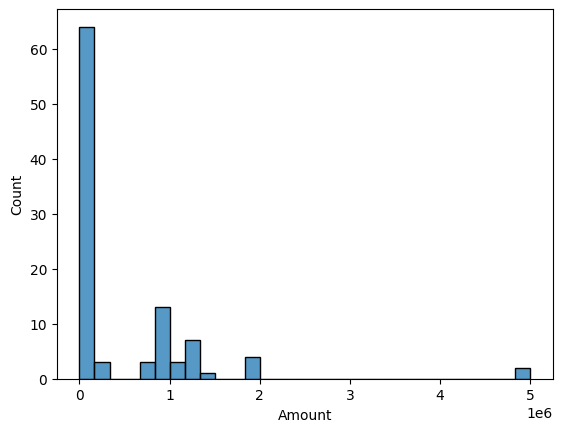

In [17]:
#Distribution of Amount
sns.histplot(df['Amount'], bins=30)
plt.show()

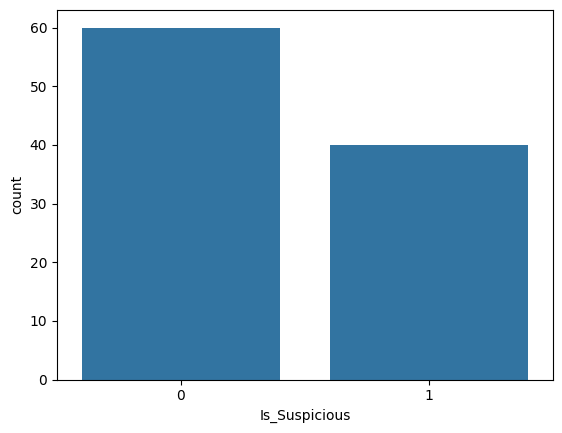

In [19]:
#Suspicious vs Normal
sns.countplot(x='Is_Suspicious', data=df)
plt.show()

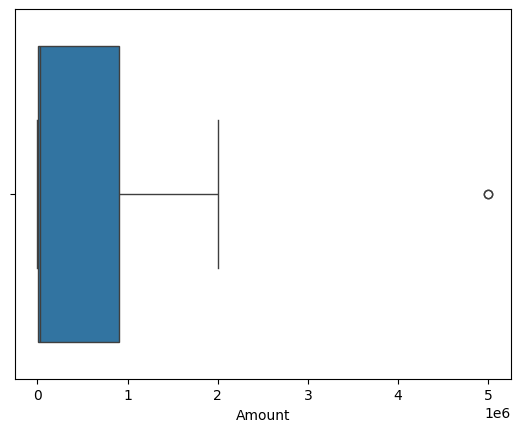

In [20]:
#Outliers
sns.boxplot(x=df['Amount'])
plt.show()

In [21]:
#Feature Engineering
df['High_Amount'] = df['Amount'] > 100000
df['New_Account'] = df['Account_Age'] < 1

In [22]:
df

,Transaction_ID,Customer_ID,Amount,Transaction_Type,Location,Time,Account_Age,Is_Suspicious,High_Amount,New_Account
0,T001,C001,5000.0,Deposit,Hyderabad,10:30,2,0,False,False
1,T002,C002,150000.0,Transfer,Mumbai,11:00,1,1,True,False
2,T003,C003,25000.0,Withdrawal,Delhi,12:15,3,0,False,False
3,T004,C004,20000.0,Deposit,Chennai,13:45,5,0,False,False
4,T005,C005,750000.0,Transfer,Bangalore,14:20,1,1,True,False
...,...,...,...,...,...,...,...,...,...,...
95,T096,C096,5000.0,Withdrawal,Bangalore,14:25,5,0,False,False
96,T097,C097,1250000.0,Transfer,Kolkata,15:15,0,1,True,True
97,T098,C098,7600.0,Deposit,Hyderabad,16:05,2,0,False,False
98,T099,C099,21000.0,Withdrawal,Mumbai,17:45,3,0,False,False


In [23]:
df['High_Amount'] = df['High_Amount'].astype(int)
df['New_Account'] = df['New_Account'].astype(int)

In [46]:
df['Time']= pd.to_datetime(df['Time'], format='%H:%M').dt.time

ValueError: unconverted data remains when parsing with format "%H:%M": ":00", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [47]:
df

,Transaction_ID,Customer_ID,Amount,Time,Account_Age,Is_Suspicious,High_Amount,New_Account,Transaction_Type_Transfer,Transaction_Type_Withdrawal,Location_Chennai,Location_Delhi,Location_Hyderabad,Location_Kolkata,Location_Mumbai,Location_unknown
0,T001,C001,5000.0,10:30:00,2,0,0,0,False,False,False,False,True,False,False,False
1,T002,C002,150000.0,11:00:00,1,1,1,0,True,False,False,False,False,False,True,False
2,T003,C003,25000.0,12:15:00,3,0,0,0,False,True,False,True,False,False,False,False
3,T004,C004,20000.0,13:45:00,5,0,0,0,False,False,True,False,False,False,False,False
4,T005,C005,750000.0,14:20:00,1,1,1,0,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,T096,C096,5000.0,14:25:00,5,0,0,0,False,True,False,False,False,False,False,False
96,T097,C097,1250000.0,15:15:00,0,1,1,1,True,False,False,False,False,True,False,False
97,T098,C098,7600.0,16:05:00,2,0,0,0,False,False,False,False,True,False,False,False
98,T099,C099,21000.0,17:45:00,3,0,0,0,False,True,False,False,False,False,True,False


In [ ]:
df[['hr','min','sec']]=df['Time'].astype(str).str.split(':', expand=True).astype(int)


In [58]:
df.dtypes

Transaction_ID                  object
Customer_ID                     object
Amount                         float64
Time                            object
Account_Age                      int64
Is_Suspicious                    int64
High_Amount                      int64
New_Account                      int64
Transaction_Type_Transfer         bool
Transaction_Type_Withdrawal       bool
Location_Chennai                  bool
Location_Delhi                    bool
Location_Hyderabad                bool
Location_Kolkata                  bool
Location_Mumbai                   bool
Location_unknown                  bool
hr                               int64
min                              int64
sec                              int64
dtype: object

In [59]:
df.drop(['Time'], axis=1, inplace=True)

In [69]:
X = df.drop(['Transaction_ID', 'Customer_ID', 'Is_Suspicious'], axis=1)
y = df['Is_Suspicious']

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [67]:
df.dtypes

Transaction_ID                  object
Customer_ID                     object
Amount                         float64
Account_Age                      int64
Is_Suspicious                    int64
High_Amount                      int64
New_Account                      int64
Transaction_Type_Transfer        int64
Transaction_Type_Withdrawal      int64
Location_Chennai                 int64
Location_Delhi                   int64
Location_Hyderabad               int64
Location_Kolkata                 int64
Location_Mumbai                  int64
Location_unknown                 int64
hr                               int64
min                              int64
sec                              int64
dtype: object

In [62]:
df = df.apply(pd.to_numeric, errors='ignore')

C:\Users\sathv\AppData\Local\Temp\ipykernel_20876\1277559549.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [66]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [84]:
model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [85]:
y_pred = model.predict(X_test)

In [86]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [87]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))

1.0


In [88]:
pip install pickle

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [89]:
import pickle

pickle.dump(rf, open("aml_model.pkl", "wb"))

In [90]:
df.groupby('Transaction_Type_Transfer')['Is_Suspicious'].mean()

Transaction_Type_Transfer
0    0.000000
1    0.930233
Name: Is_Suspicious, dtype: float64

In [79]:
df.to_csv('cleaned_data.csv', index=False)
 